# Recover simulated Gaia astrometric orbits with JAXoplanet + NumPyro

This notebook loads one simulated system from the per-population HDF5 files (`simulated_astrometry_<population>_systems.h5`, each with a `/truths` table (one row per system) and `/systems/<i>/epochs` datasets) and fits the **same data** with 0-, 1-, and 2-planet models. The along-scan convention, Gaia reference epoch, and stellar-reflex calculation match `sim_astrometry.ipynb`.

The system to fit is chosen automatically as a high-S/N (clearly detectable) system, ranked by the injected total detectability S/N stored in `/truths` (`SNR_RANK`), so the selection stays valid across simulation reruns without hard-coded indices.

The five standard astrometric parameters use broad Uniform priors initialized by weighted least squares, and each companion's orbit is parameterized as: log-period, log-mass, an `h/k = (sqrt(e) cos w, sqrt(e) sin w)` eccentricity reparameterization, `cos i`, `Omega`, and `M0`. Injected orbital truth is optional and is used only to initialize NUTS and annotate plots; it is never used in the likelihood. Rather than a multiplicative error scale, the likelihood adds a fitted along-scan **jitter in quadrature** to the reported per-transit uncertainty, `sigma_eff = sqrt(sigma_reported^2 + jitter^2)`, which absorbs any mismatch between the reported error and the injected scatter (the simulation draws noise from `sigma_UEVA` but writes `sigma_reported` to `centroid_pos_error_al`).


In [10]:
from pathlib import Path
import warnings

import jax
import jax.numpy as jnp
from jax.scipy.special import logsumexp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive, init_to_value
from numpyro.infer.util import log_likelihood
from jaxoplanet.orbits.keplerian import Central, System

jax.config.update("jax_enable_x64", True)
print("JAX devices:", jax.devices())
print("NumPyro version:", numpyro.__version__)

JAX devices: [CpuDevice(id=0)]
NumPyro version: 0.16.1


## Configuration

Set `DATASET_POPULATION` to a released population (`0_companion`, `1_companion_agnostic`, `1_companion_detectable`, `2_companion_agnostic`, `2_companion_detectable`). The loader reads that population's `simulated_astrometry_<population>_systems.h5` file, restricts to systems whose injected companion periods are all shorter than the DR4 baseline (`DR4_BASELINE_YEARS`), ranks those by injected total detectability S/N (`/truths`), and fits the `SNR_RANK`-th highest-S/N system (`0` = highest) with every entry in `MODEL_ORDERS`. The period cut keeps the selection well-conditioned: purely S/N-ranked systems tend to be very massive, long-period companions whose orbits exceed the observing window and are hard to constrain.

Selecting by S/N rather than a fixed index keeps the choice valid across simulation reruns: high-S/N systems have a large astrometric signature $\alpha = (M_p/M_\star)\,a\,\varpi$ accumulated over many transits, so they are the ones expected to be recoverable. Increase `SNR_RANK` to step through the next-brightest detectable systems; increase the chain lengths for scientific conclusions.


In [11]:
DATA_ROOT = Path("outputs/data")

# The astrometry is released as one self-describing HDF5 file per population,
# each with a /truths table (one row per system) and /systems/<i>/epochs datasets.
DATASET_POPULATION = "2_companion_detectable"  # detectable => should be recoverable
SYSTEMS_H5 = DATA_ROOT / f"simulated_astrometry_{DATASET_POPULATION}_systems.h5"

# Rather than a hard-coded system index, select a high-S/N (clearly detectable)
# system by rank in descending total detectability S/N (0 = highest).
SNR_RANK = 0
N_SNR_PREVIEW = 8  # number of top-S/N candidates to preview

# Keep only well-conditioned systems: every injected companion period shorter
# than the DR4 baseline (so each orbit is covered within the observing window).
DR4_BASELINE_YEARS = 5.5
SNR_MIN = 0.0  # optional floor on total detectability S/N

MODEL_ORDERS = (0, 1, 2)

USE_INJECTED_INIT = True  # recovery test; set False for a blind search
NUM_WARMUP = 500
NUM_SAMPLES = 500
NUM_CHAINS = 2
RNG_SEED = 2026
TARGET_ACCEPT = 0.9

PERIOD_MIN_YEARS = 0.1
PERIOD_MAX_YEARS = 5000.0
GAIA_EPOCH_TCB_JD = 2457936.875
RSUN_TO_AU = 0.00465047
MJUP_TO_MSUN = 0.000954588
MARS_TO_MSUN = 0.107 * 3.0034896e-6
MAX_COMPANION_MASS_MSUN = 80.0 * MJUP_TO_MSUN

TWOPI = 2.0 * np.pi
ECC_MAX = 0.99

# Along-scan jitter added in quadrature (replaces a multiplicative error scale):
#   sigma_eff = sqrt(sigma_reported^2 + jitter^2)
AL_JITTER_MIN_MAS = 1.0e-3
AL_JITTER_MAX_MAS = 5.0


In [12]:
import h5py


def _decode_str_cols(df):
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].map(
                lambda v: v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
            )
    return df


def load_truths(systems_h5):
    """Per-population /truths table (one row per system) as a DataFrame."""
    systems_h5 = Path(systems_h5)
    if not systems_h5.exists():
        raise FileNotFoundError(f"Missing per-population systems file: {systems_h5}")
    with h5py.File(systems_h5, "r") as f:
        truths = pd.DataFrame(f["truths"][:])
    return _decode_str_cols(truths)


def total_snr(truths):
    """Detectability S/N per system: max total S/N over the injected companions."""
    cols = [c for c in ("snr_total_1", "snr_total_2") if c in truths.columns]
    if not cols:
        return np.zeros(len(truths))
    return np.nanmax(truths[cols].to_numpy(float), axis=1)


def high_snr_rows(truths, min_snr=None):
    """Row indices into /truths sorted by descending detectability S/N."""
    snr = total_snr(truths)
    order = np.argsort(-np.nan_to_num(snr, nan=-np.inf))
    if min_snr is not None:
        order = order[snr[order] >= min_snr]
    return order, snr


def max_injected_period_years(truths):
    """Longest injected companion period per system [yr]; inf if none injected."""
    cols = [c for c in ("period_1", "period_2") if c in truths.columns]
    if not cols:
        return np.full(len(truths), np.inf)
    with np.errstate(invalid="ignore"):
        pmax = np.nanmax(truths[cols].to_numpy(float), axis=1)
    return np.where(np.isfinite(pmax), pmax, np.inf)


def select_systems(truths, baseline_years, min_snr=0.0):
    """Row indices sorted by descending total detectability S/N, restricted to
    systems whose injected companion periods are ALL shorter than the DR4
    baseline (each orbit completes within the observing window, so the fit is
    well conditioned) and whose total S/N is at least ``min_snr``."""
    snr = total_snr(truths)
    pmax = max_injected_period_years(truths)
    eligible = (pmax < baseline_years) & (snr >= min_snr)
    order = np.argsort(-np.nan_to_num(snr, nan=-np.inf))
    return order[eligible[order]], snr, pmax


def load_simulated_system(systems_h5, row_index):
    """Load truth + epoch table for the system at /truths row `row_index`."""
    systems_h5 = Path(systems_h5)
    with h5py.File(systems_h5, "r") as f:
        truths = _decode_str_cols(pd.DataFrame(f["truths"][:]))
        if not (0 <= row_index < len(truths)):
            raise IndexError(f"row_index {row_index} out of range (n={len(truths)})")
        truth = truths.iloc[row_index]
        group = f[f"systems/{row_index}"]
        if "epochs" not in group:
            raise KeyError(f"No epochs for row {row_index} ({truth['system_id']})")
        epochs = _decode_str_cols(pd.DataFrame(group["epochs"][:]))

    epochs = epochs.sort_values("obs_time_tcb").reset_index(drop=True)
    required = {
        "obs_time_tcb", "centroid_pos_al", "centroid_pos_error_al",
        "parallax_factor_al", "scan_pos_angle", "gaia_source_id", "source_id_dr2",
    }
    missing = required.difference(epochs.columns)
    if missing:
        raise ValueError(f"epochs missing columns: {sorted(missing)}")
    if str(truth["gaia_source_id"]) != str(epochs["gaia_source_id"].iloc[0]) or \
       str(truth["source_id_dr2"]) != str(epochs["source_id_dr2"].iloc[0]):
        raise ValueError("Epoch and truth Gaia identifiers do not match")

    return {
        "system_id": truth["system_id"], "epochs": epochs, "truth": truth,
        "row_index": row_index, "gaia_source_id": truth["gaia_source_id"],
        "source_id_dr2": truth["source_id_dr2"], "path": systems_h5,
    }


# --- select a high-S/N, well-conditioned system: large total detectability S/N
#     AND all injected companion periods shorter than the DR4 baseline. ---
truths_table = load_truths(SYSTEMS_H5)
sel_order, snr_values, pmax_years = select_systems(
    truths_table, DR4_BASELINE_YEARS, min_snr=SNR_MIN
)
if len(sel_order) == 0:
    raise ValueError(
        f"No {DATASET_POPULATION} systems with all companion periods < "
        f"{DR4_BASELINE_YEARS} yr and total S/N >= {SNR_MIN}"
    )

preview = truths_table.iloc[sel_order[:N_SNR_PREVIEW]].copy()
preview["total_snr"] = snr_values[sel_order[:N_SNR_PREVIEW]]
preview["max_period_yr"] = pmax_years[sel_order[:N_SNR_PREVIEW]]
print(f"{DATASET_POPULATION}: {len(sel_order)}/{len(truths_table)} systems with all "
      f"periods < {DR4_BASELINE_YEARS} yr; top {N_SNR_PREVIEW} by total S/N:")
display(preview[["system_id", "n_planets", "total_snr", "max_period_yr"]].reset_index(drop=True))

ROW_INDEX = int(sel_order[SNR_RANK])
dataset = load_simulated_system(SYSTEMS_H5, ROW_INDEX)
epochs = dataset["epochs"]
truth = dataset["truth"]

t_years = (epochs["obs_time_tcb"].to_numpy(float) - GAIA_EPOCH_TCB_JD) / 365.25
psi = epochs["scan_pos_angle"].to_numpy(float)
parallax_factor = epochs["parallax_factor_al"].to_numpy(float)
y = epochs["centroid_pos_al"].to_numpy(float)
yerr = epochs["centroid_pos_error_al"].to_numpy(float)
MSTAR = float(truth["mass_st_msun"])
RSTAR = float(truth["radius_st_rsun"])

print(f"\nSelected SNR rank {SNR_RANK}: {dataset['system_id']} "
      f"(row {ROW_INDEX}, total S/N = {snr_values[ROW_INDEX]:.1f})")
print("Source key:", dataset["gaia_source_id"], dataset["source_id_dr2"])
print(f"Epochs: {len(y)}; baseline: {np.ptp(t_years):.2f} yr; Mstar={MSTAR:.3f} Msun")
print("Injected planets:", int(truth["n_planets"]))

# injected truth orbital parameters for the selected system
n_injected = int(truth["n_planets"])
if n_injected == 0:
    print("Injected truth: companion-free control (no orbital parameters).")
else:
    truth_rows = []
    for idx in range(1, n_injected + 1):
        truth_rows.append({
            "companion": idx,
            "a_au": float(truth[f"a_{idx}_au"]),
            "period_yr": float(truth[f"period_{idx}"]),
            "Mp_Mjup": float(truth[f"Mp_{idx}_msun"]) / MJUP_TO_MSUN,
            "e": float(truth[f"e_{idx}"]),
            "i_deg": np.degrees(float(truth[f"i_{idx}_rad"])),
            "Omega_deg": np.degrees(float(truth[f"Omega_{idx}_rad"])),
            "omega_deg": np.degrees(float(truth[f"omega_{idx}_rad"])),
            "M0_deg": np.degrees(float(truth[f"M0_{idx}_rad"])),
            "alpha_mas": float(truth[f"alpha_{idx}_mas"]),
            "snr_total": float(truth[f"snr_total_{idx}"]),
        })
    print("\nInjected truth orbital parameters:")
    display(pd.DataFrame(truth_rows).set_index("companion").round(3))


2_companion_detectable: 334/10653 systems with all periods < 5.5 yr; top 8 by total S/N:


,system_id,n_planets,total_snr,max_period_yr
0,2_companion_detectable_SYS_0010211,2,948.999294,5.391312
1,2_companion_detectable_SYS_0002526,2,878.478511,4.709996
2,2_companion_detectable_SYS_0007804,2,871.923041,3.770933
3,2_companion_detectable_SYS_0008374,2,718.715373,4.038504
4,2_companion_detectable_SYS_0006520,2,636.637626,3.311812
5,2_companion_detectable_SYS_0003439,2,624.828318,4.649665
6,2_companion_detectable_SYS_0008820,2,480.565856,2.895894
7,2_companion_detectable_SYS_0005705,2,465.807724,4.956660



Selected SNR rank 0: 2_companion_detectable_SYS_0010211 (row 10211, total S/N = 949.0)
Source key: 4423007800173036544 4423007800173036544
Epochs: 62; baseline: 5.35 yr; Mstar=0.130 Msun
Injected planets: 2

Injected truth orbital parameters:


,a_au,period_yr,Mp_Mjup,e,i_deg,Omega_deg,omega_deg,M0_deg,alpha_mas,snr_total
companion,,,,,,,,,,
1,1.099,2.704,53.394,0.104,106.741,287.842,128.191,288.872,17.193,948.999
2,1.726,5.391,48.564,0.059,101.226,320.469,159.510,7.442,25.203,807.263


,parameter,WLS,WLS_sigma,prior_scale
0,alpha0_mas,5.965292,0.012437,10.0
1,delta0_mas,-9.600816,0.009763,10.0
2,pmra_mas_yr,-214.753447,0.007049,10.0
3,pmdec_mas_yr,-64.990529,0.004995,10.0
4,parallax_mas,56.784712,0.015065,5.0


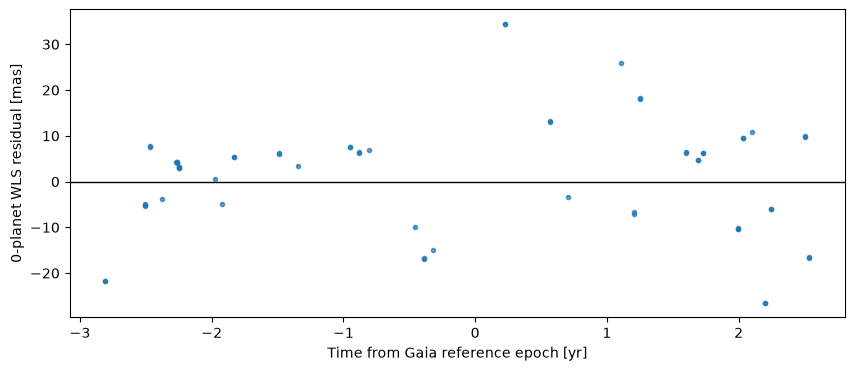

In [13]:
def astrometric_design_matrix(t, scan_angle, pf):
    return np.column_stack([
        np.sin(scan_angle), np.cos(scan_angle),
        np.sin(scan_angle) * t, np.cos(scan_angle) * t, pf,
    ])


def weighted_linear_solution(t, scan_angle, pf, values, errors):
    X = astrometric_design_matrix(t, scan_angle, pf)
    w = 1.0 / np.square(errors)
    normal = X.T @ (w[:, None] * X)
    covariance = np.linalg.pinv(normal)
    beta = covariance @ (X.T @ (w * values))
    return beta, covariance, X


beta_wls, beta_cov, X = weighted_linear_solution(t_years, psi, parallax_factor, y, yerr)
beta_names = ["alpha0_mas", "delta0_mas", "pmra_mas_yr", "pmdec_mas_yr", "parallax_mas"]

# WLS-informed Gaussian priors on the five astrometric nuisances: centered on the
# weighted-least-squares solution, with a scale of a few x the WLS uncertainty
# (floored so that a very well-constrained fit still leaves the companion room to
# move the linear parameters). Parallax uses a positive-truncated normal.
beta_sigma = np.sqrt(np.diag(beta_cov))
beta_prior_scale = np.maximum(10.0 * beta_sigma, np.array([10.0, 10.0, 10.0, 10.0, 5.0]))

display(pd.DataFrame({
    "parameter": beta_names, "WLS": beta_wls,
    "WLS_sigma": beta_sigma, "prior_scale": beta_prior_scale,
}))

fig, ax = plt.subplots(figsize=(10, 4))
ax.errorbar(t_years, y - X @ beta_wls, yerr=yerr, fmt=".", alpha=0.7)
ax.axhline(0, color="k", lw=1)
ax.set(xlabel="Time from Gaia reference epoch [yr]", ylabel="0-planet WLS residual [mas]")
plt.show()


In [14]:
def stellar_reflex_al(t, scan_angle, parallax_mas, planets, mstar=MSTAR, rstar=RSTAR):
    """JAXoplanet stellar reflex projected into Gaia along-scan coordinates."""
    t_days = jnp.asarray(t) * 365.25
    system = System(Central(mass=jnp.asarray(mstar), radius=jnp.asarray(rstar)))

    for planet in planets:
        period_days = planet["period_years"] * 365.25
        mean_motion = 2.0 * jnp.pi / period_days
        system = system.add_body(
            period=period_days, mass=planet["mass_msun"],
            eccentricity=planet["eccentricity"], inclination=planet["inclination"],
            omega_peri=planet["omega"], asc_node=planet["Omega"],
            time_peri=-planet["M0"] / mean_motion,
        )

    x_rsun = jnp.zeros_like(t_days)
    y_rsun = jnp.zeros_like(t_days)
    for body in system.bodies:
        x_body, y_body, _ = body.central_position(t_days)
        x_rsun = x_rsun + x_body
        y_rsun = y_rsun + y_body

    x_mas = x_rsun * RSUN_TO_AU * parallax_mas
    y_mas = y_rsun * RSUN_TO_AU * parallax_mas
    return -(x_mas * jnp.cos(scan_angle) + y_mas * jnp.sin(scan_angle))


def build_astrometric_model(n_planets, beta_loc, beta_scale):
    """Along-scan model in the gaia4b5b style, with WLS-informed Gaussian priors
    on the five astrometric nuisances (centered on the weighted-least-squares
    solution), an h/k = (sqrt(e) cos w, sqrt(e) sin w)
    eccentricity reparameterization, and an along-scan jitter added in
    quadrature to the reported per-transit uncertainty (rather than a
    multiplicative error scale). The stellar reflex uses jaxoplanet in the same
    (sign-corrected) native-Gaia convention as sim_astrometry.ipynb."""
    log_period_min, log_period_max = np.log(PERIOD_MIN_YEARS), np.log(PERIOD_MAX_YEARS)
    log_mass_min = np.log(MARS_TO_MSUN / MJUP_TO_MSUN)                # log Mjup
    log_mass_max = np.log(MAX_COMPANION_MASS_MSUN / MJUP_TO_MSUN)
    root_e_max = float(np.sqrt(ECC_MAX))
    log_jit_min, log_jit_max = np.log(AL_JITTER_MIN_MAS), np.log(AL_JITTER_MAX_MAS)

    def model(t, scan_angle, pf, reported_error, observed=None):
        # five-parameter astrometric nuisances (WLS-informed Gaussian priors)
        alpha0 = numpyro.sample("alpha0_mas", dist.Normal(beta_loc[0], beta_scale[0]))
        delta0 = numpyro.sample("delta0_mas", dist.Normal(beta_loc[1], beta_scale[1]))
        pmra = numpyro.sample("pmra_mas_yr", dist.Normal(beta_loc[2], beta_scale[2]))
        pmdec = numpyro.sample("pmdec_mas_yr", dist.Normal(beta_loc[3], beta_scale[3]))
        parallax = numpyro.sample(
            "parallax_mas", dist.TruncatedNormal(beta_loc[4], beta_scale[4], low=1.0e-3)
        )
        # along-scan jitter, added in quadrature to the reported error below
        log_al_jitter = numpyro.sample("log_al_jitter_mas", dist.Uniform(log_jit_min, log_jit_max))

        # per-companion orbital parameters
        period_logs = [
            numpyro.sample(f"log_period_{i}", dist.Uniform(log_period_min, log_period_max))
            for i in range(1, n_planets + 1)
        ]
        if n_planets == 2:  # label inner = 1 / outer = 2 by sorting the periods
            period_logs = list(jnp.sort(jnp.stack(period_logs)))

        planets = []
        for idx in range(1, n_planets + 1):
            log_mass = numpyro.sample(f"log_mass_{idx}", dist.Uniform(log_mass_min, log_mass_max))
            h = numpyro.sample(f"h_{idx}", dist.Uniform(-root_e_max, root_e_max))
            k = numpyro.sample(f"k_{idx}", dist.Uniform(-root_e_max, root_e_max))
            eccentricity = h**2 + k**2
            numpyro.factor(f"ecc_bound_{idx}", jnp.where(eccentricity < ECC_MAX, 0.0, -jnp.inf))
            cos_i = numpyro.sample(f"cos_i_{idx}", dist.Uniform(-1.0, 1.0))
            Omega = numpyro.sample(f"Omega_{idx}", dist.Uniform(0.0, TWOPI))
            M0 = numpyro.sample(f"M0_{idx}", dist.Uniform(0.0, TWOPI))
            period_years = jnp.exp(period_logs[idx - 1])
            mass_mjup = jnp.exp(log_mass)
            numpyro.deterministic(f"period_years_{idx}", period_years)
            numpyro.deterministic(f"mass_mjup_{idx}", mass_mjup)
            numpyro.deterministic(f"eccentricity_{idx}", eccentricity)
            numpyro.deterministic(f"omega_{idx}", jnp.arctan2(k, h) % TWOPI)
            planets.append({
                "period_years": period_years, "mass_msun": mass_mjup * MJUP_TO_MSUN,
                "eccentricity": eccentricity, "inclination": jnp.arccos(cos_i),
                "omega": jnp.arctan2(k, h), "Omega": Omega, "M0": M0,
            })

        sin_psi, cos_psi = jnp.sin(scan_angle), jnp.cos(scan_angle)
        astrometry = (
            sin_psi * (alpha0 + pmra * t) + cos_psi * (delta0 + pmdec * t) + parallax * pf
        )
        reflex = stellar_reflex_al(t, scan_angle, parallax, planets) if n_planets else 0.0
        mu = numpyro.deterministic("mu", astrometry + reflex)
        sigma = jnp.sqrt(reported_error**2 + jnp.exp(log_al_jitter)**2)
        numpyro.sample("obs", dist.Normal(mu, sigma), obs=observed)

    return model


In [15]:
def injected_planets(truth_row):
    if truth_row is None:
        return []
    planets = []
    for idx in range(1, int(truth_row["n_planets"]) + 1):
        mass_msun = float(truth_row[f"Mp_{idx}_msun"])
        a_au = float(truth_row[f"a_{idx}_au"])
        planets.append({
            "period_years": np.sqrt(a_au**3 / (MSTAR + mass_msun)),
            "mass_msun": mass_msun, "eccentricity": float(truth_row[f"e_{idx}"]),
            "cos_i": np.cos(float(truth_row[f"i_{idx}_rad"])),
            "Omega": float(truth_row[f"Omega_{idx}_rad"]) % (2 * np.pi),
            "omega": float(truth_row[f"omega_{idx}_rad"]) % (2 * np.pi),
            "M0": float(truth_row[f"M0_{idx}_rad"]) % (2 * np.pi),
        })
    return sorted(planets, key=lambda p: p["period_years"])


def make_initial_values(n_planets, use_truth=USE_INJECTED_INIT):
    values = {
        "alpha0_mas": float(beta_wls[0]), "delta0_mas": float(beta_wls[1]),
        "pmra_mas_yr": float(beta_wls[2]), "pmdec_mas_yr": float(beta_wls[3]),
        "parallax_mas": float(beta_wls[4]),
        "log_al_jitter_mas": float(np.log(np.sqrt(AL_JITTER_MIN_MAS * AL_JITTER_MAX_MAS))),
    }
    injected = injected_planets(truth) if use_truth else []
    defaults = [
        {"period_years": 2.0, "mass_msun": MJUP_TO_MSUN, "eccentricity": 0.2,
         "cos_i": 0.0, "Omega": 1.0, "omega": 2.0, "M0": 0.5},
        {"period_years": 8.0, "mass_msun": MJUP_TO_MSUN, "eccentricity": 0.2,
         "cos_i": 0.0, "Omega": 2.0, "omega": 1.0, "M0": 1.5},
    ]
    starts = sorted((injected + defaults[len(injected):])[:n_planets], key=lambda p: p["period_years"])
    lp_min, lp_max = np.log(PERIOD_MIN_YEARS), np.log(PERIOD_MAX_YEARS)
    lm_min, lm_max = np.log(MARS_TO_MSUN / MJUP_TO_MSUN), np.log(MAX_COMPANION_MASS_MSUN / MJUP_TO_MSUN)
    root_e_max = float(np.sqrt(ECC_MAX))
    for idx, planet in enumerate(starts, start=1):
        e = float(np.clip(planet["eccentricity"], 1e-4, ECC_MAX - 1e-3))
        omega = float(planet["omega"]) % (2 * np.pi)
        values[f"log_period_{idx}"] = float(np.clip(np.log(planet["period_years"]), lp_min + 1e-4, lp_max - 1e-4))
        values[f"log_mass_{idx}"] = float(np.clip(np.log(planet["mass_msun"] / MJUP_TO_MSUN), lm_min + 1e-4, lm_max - 1e-4))
        values[f"h_{idx}"] = float(np.clip(np.sqrt(e) * np.cos(omega), -root_e_max + 1e-4, root_e_max - 1e-4))
        values[f"k_{idx}"] = float(np.clip(np.sqrt(e) * np.sin(omega), -root_e_max + 1e-4, root_e_max - 1e-4))
        values[f"cos_i_{idx}"] = float(np.clip(planet["cos_i"], -0.9999, 0.9999))
        values[f"Omega_{idx}"] = float(np.clip(planet["Omega"] % (2 * np.pi), 1e-4, 2 * np.pi - 1e-4))
        values[f"M0_{idx}"] = float(np.clip(planet["M0"] % (2 * np.pi), 1e-4, 2 * np.pi - 1e-4))
    return values


def fit_model(n_planets, rng_key, num_warmup=NUM_WARMUP, num_samples=NUM_SAMPLES):
    model = build_astrometric_model(n_planets, beta_wls, beta_prior_scale)
    init_values = make_initial_values(n_planets)
    kernel = NUTS(
        model, init_strategy=init_to_value(values=init_values),
        target_accept_prob=TARGET_ACCEPT, dense_mass=True,
    )
    sampler = MCMC(
        kernel, num_warmup=num_warmup, num_samples=num_samples,
        num_chains=NUM_CHAINS, chain_method="sequential", progress_bar=True,
    )
    sampler.run(
        rng_key, jnp.asarray(t_years), jnp.asarray(psi), jnp.asarray(parallax_factor),
        jnp.asarray(yerr), observed=jnp.asarray(y),
        extra_fields=("potential_energy",),
    )
    return {"model": model, "sampler": sampler, "samples": sampler.get_samples()}


## Run the three MCMC fits

The first run for each model includes JAX compilation. A two-planet astrometric posterior can be strongly multimodal; truth initialization tests local recovery, not whether a blind search finds the correct mode.

In [16]:
fits = {}
keys = jax.random.split(jax.random.key(RNG_SEED), len(MODEL_ORDERS))
for order, key in zip(MODEL_ORDERS, keys):
    print("\n" + "=" * 72)
    print(f"Fitting {order}-planet model to {dataset['system_id']}")
    print("=" * 72)
    fits[order] = fit_model(order, key)
    fits[order]["sampler"].print_summary(exclude_deterministic=True)


Fitting 0-planet model to 2_companion_detectable_SYS_0010211


sample: 100%|██████████| 1000/1000 [00:00<00:00, 2935.50it/s, 7 steps of size 6.44e-01. acc. prob=0.90]



                         mean       std    median      5.0%     95.0%     n_eff     r_hat
         alpha0_mas      5.90      1.01      5.90      4.35      7.57   1511.53      1.00
         delta0_mas     -9.65      0.80     -9.64    -11.01     -8.35   1759.35      1.00
  log_al_jitter_mas      1.61      0.00      1.61      1.60      1.61   1300.79      1.00
       parallax_mas     57.07      1.33     57.08     55.14     59.57   1567.90      1.00
       pmdec_mas_yr    -65.09      0.43    -65.08    -65.83    -64.46   1418.60      1.00
        pmra_mas_yr   -214.93      0.61   -214.94   -215.90   -213.92   1357.77      1.00

Number of divergences: 0

Fitting 1-planet model to 2_companion_detectable_SYS_0010211


sample: 100%|██████████| 1000/1000 [00:01<00:00, 509.63it/s, 31 steps of size 1.90e-01. acc. prob=0.93]



                         mean       std    median      5.0%     95.0%     n_eff     r_hat
               M0_1      6.14      0.11      6.16      5.99      6.28    253.69      1.00
            Omega_1      5.31      0.08      5.30      5.19      5.43    901.05      1.00
         alpha0_mas     10.61      2.64     10.66      6.74     15.59    464.56      1.00
            cos_i_1     -0.04      0.07     -0.04     -0.16      0.07    667.41      1.01
         delta0_mas    -10.65      1.98    -10.66    -13.67     -7.26    525.60      1.00
                h_1      0.41      0.09      0.42      0.26      0.56    247.59      1.01
                k_1      0.58      0.10      0.59      0.42      0.75    320.46      1.00
  log_al_jitter_mas      1.60      0.01      1.61      1.60      1.61   1137.58      1.00
         log_mass_1      4.32      0.06      4.34      4.24      4.38   1091.82      1.00
       log_period_1      0.88      0.01      0.88      0.86      0.90    903.85      1.00
       pa

sample: 100%|██████████| 1000/1000 [00:25<00:00, 39.66it/s, 121 steps of size 6.84e-03. acc. prob=0.85]


                         mean       std    median      5.0%     95.0%     n_eff     r_hat
               M0_1      5.01      0.04      5.01      4.94      5.08    411.03      1.00
               M0_2      4.03      0.58      4.18      3.19      4.96      7.93      1.14
            Omega_1      4.99      0.02      4.99      4.95      5.02     36.65      1.05
            Omega_2      5.59      0.00      5.59      5.59      5.60    615.51      1.00
         alpha0_mas      1.19      0.77      1.12     -0.07      2.43     43.46      1.05
            cos_i_1     -0.33      0.01     -0.33     -0.35     -0.31     26.62      1.19
            cos_i_2     -0.21      0.01     -0.21     -0.22     -0.20     67.79      1.02
         delta0_mas     -2.76      0.87     -2.64     -4.10     -1.39     33.28      1.15
                h_1     -0.23      0.01     -0.23     -0.25     -0.20     98.36      1.05
                h_2      0.08      0.10      0.07     -0.10      0.23     21.48      1.14
         

,n_planets,WAIC,p_WAIC,divergences,delta_WAIC
2,2,-73.418109,15.876500,32,0.000000
1,1,603.521709,42.821630,0,676.939818
0,0,742.652443,30.722713,0,816.070552


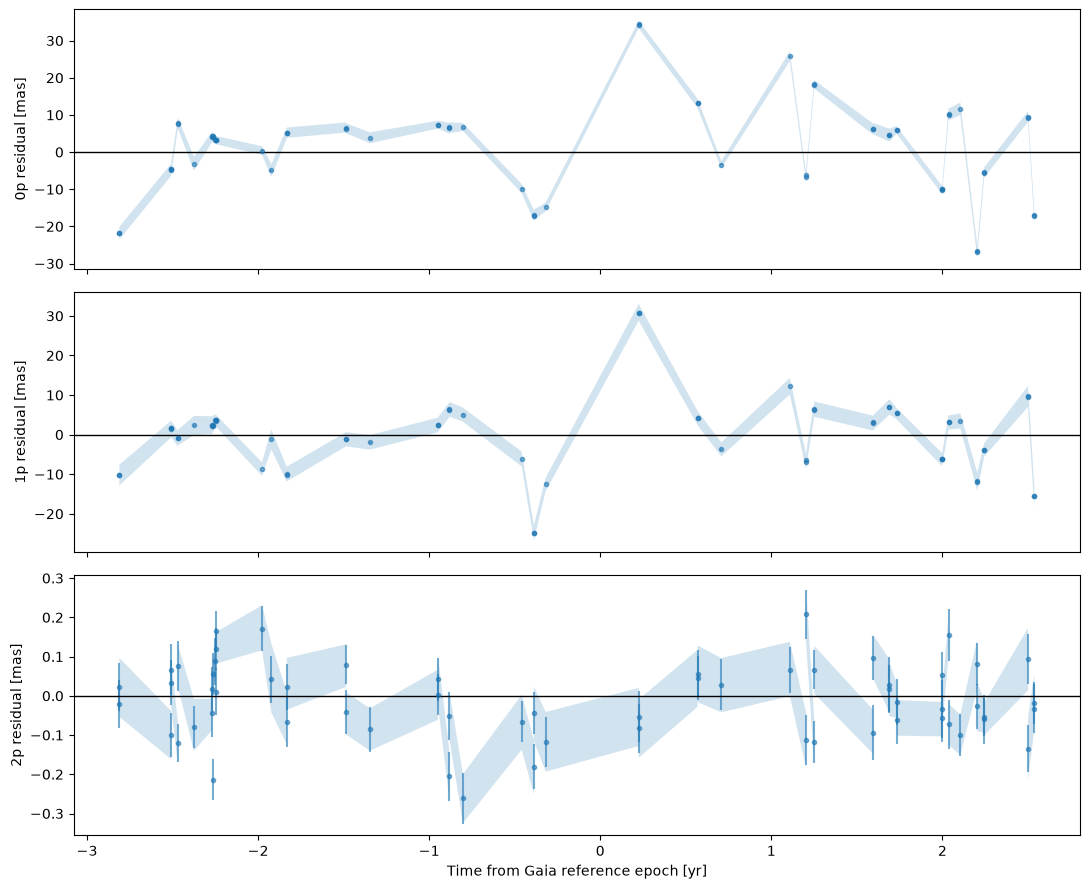

In [17]:
def compute_waic(fit):
    ll = np.asarray(log_likelihood(
        fit["model"], fit["samples"],
        jnp.asarray(t_years), jnp.asarray(psi), jnp.asarray(parallax_factor),
        jnp.asarray(yerr), observed=jnp.asarray(y),
    )["obs"])
    lppd = np.sum(logsumexp(jnp.asarray(ll), axis=0) - np.log(ll.shape[0]))
    p_waic = np.sum(np.var(ll, axis=0, ddof=1))
    return float(-2.0 * (lppd - p_waic)), float(p_waic)


comparison = []
for order, fit in fits.items():
    waic, p_waic = compute_waic(fit)
    divergent = int(np.asarray(fit["sampler"].get_extra_fields()["diverging"]).sum())
    comparison.append({"n_planets": order, "WAIC": waic, "p_WAIC": p_waic, "divergences": divergent})
comparison = pd.DataFrame(comparison).sort_values("WAIC")
comparison["delta_WAIC"] = comparison["WAIC"] - comparison["WAIC"].min()
display(comparison)

fig, axes = plt.subplots(len(fits), 1, figsize=(11, 3 * len(fits)), sharex=True)
axes = np.atleast_1d(axes)
for ax, (order, fit) in zip(axes, fits.items()):
    predictive = Predictive(fit["model"], posterior_samples=fit["samples"], return_sites=["mu"])
    mu = np.asarray(predictive(
        jax.random.key(100 + order), jnp.asarray(t_years), jnp.asarray(psi),
        jnp.asarray(parallax_factor), jnp.asarray(yerr), observed=None,
    )["mu"])
    median = np.median(mu, axis=0)
    lo, hi = np.percentile(mu, [16, 84], axis=0)
    ax.errorbar(t_years, y - median, yerr=yerr, fmt=".", alpha=0.6)
    ax.fill_between(t_years, y - hi, y - lo, alpha=0.2)
    ax.axhline(0, color="k", lw=1)
    ax.set_ylabel(f"{order}p residual [mas]")
axes[-1].set_xlabel("Time from Gaia reference epoch [yr]")
plt.tight_layout()
plt.show()

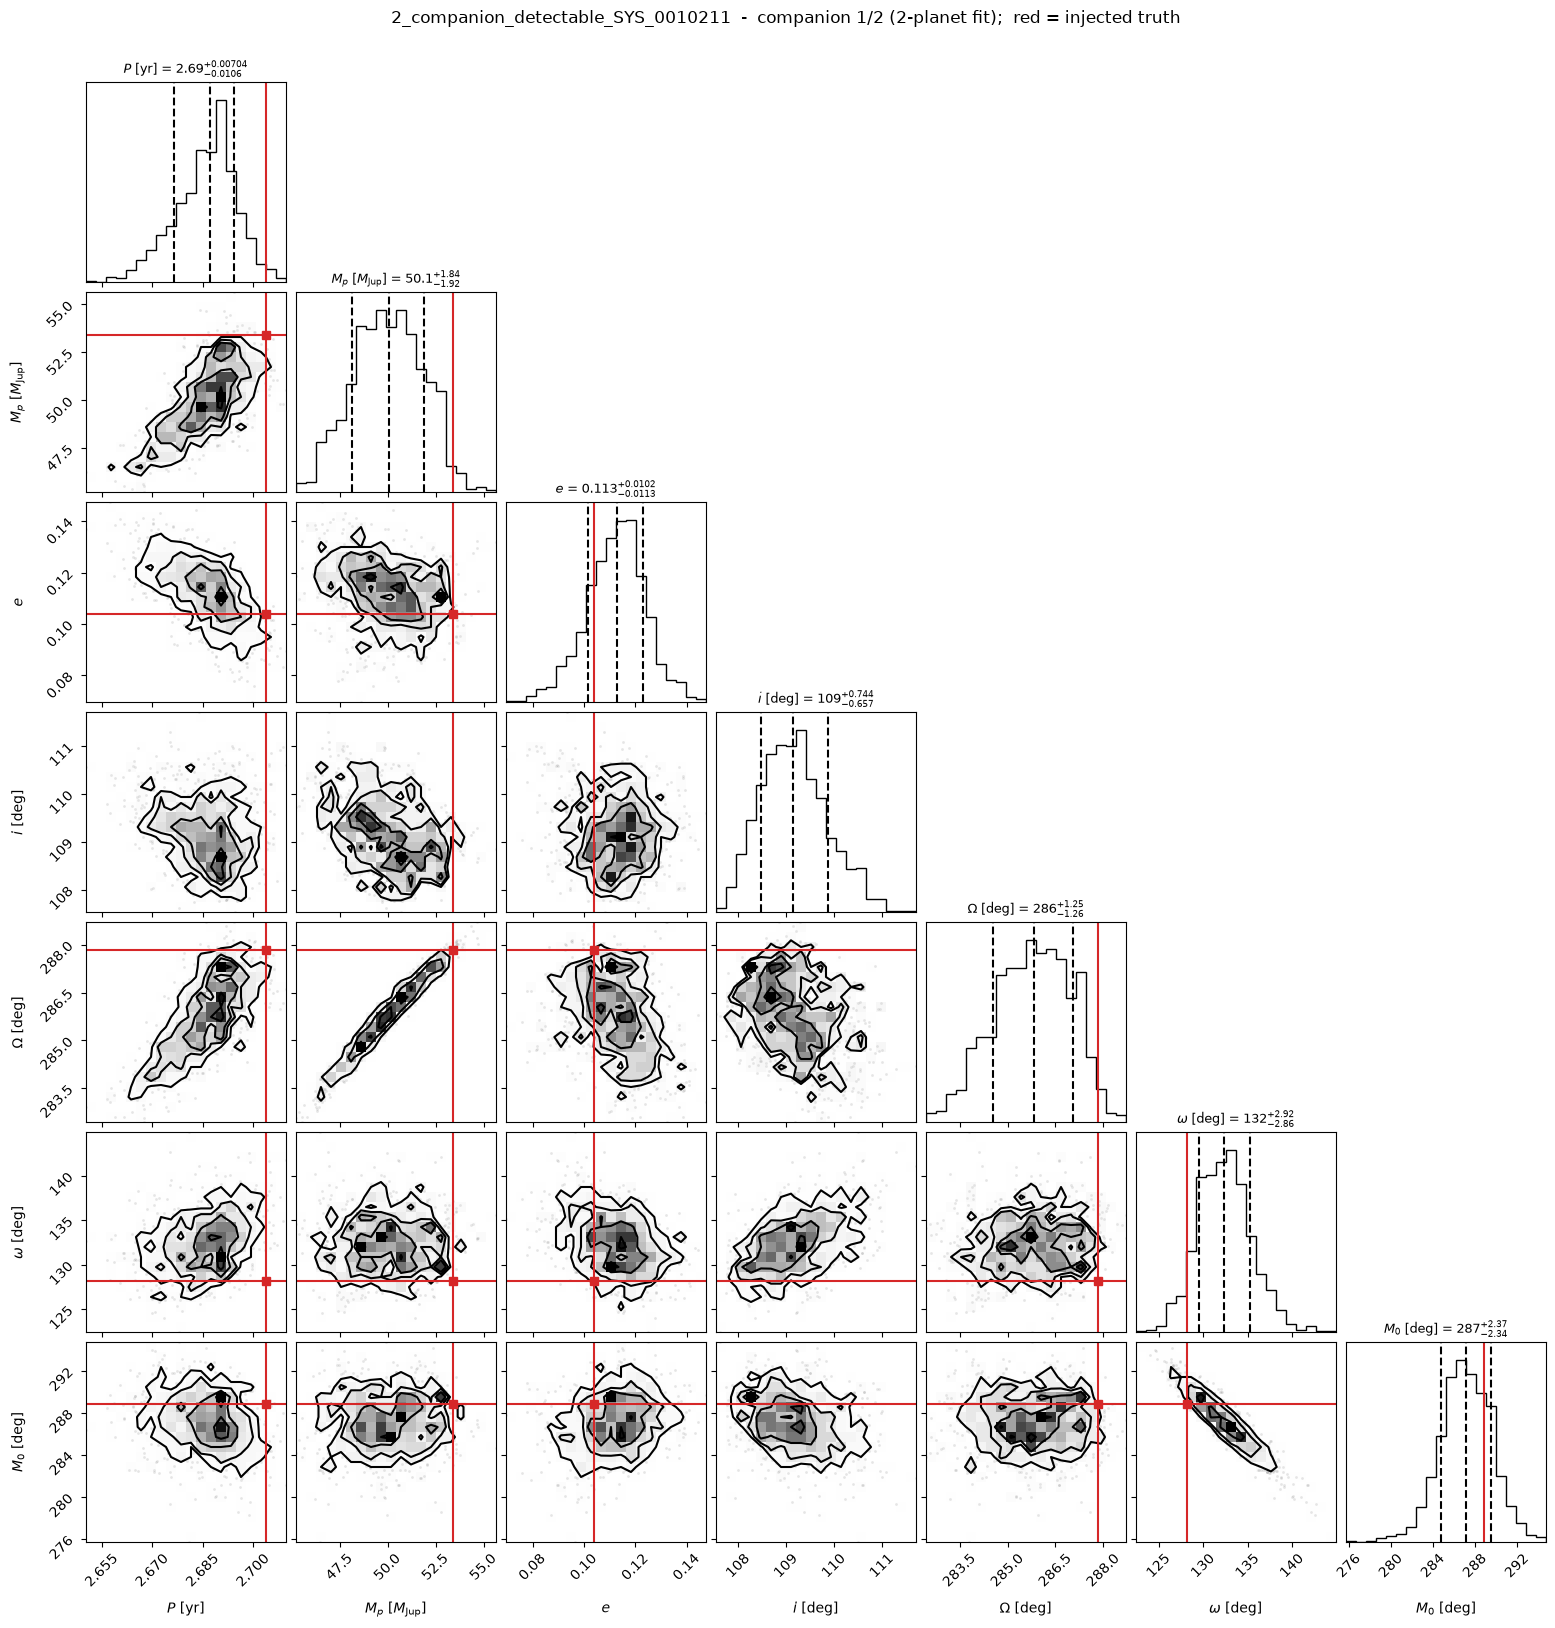

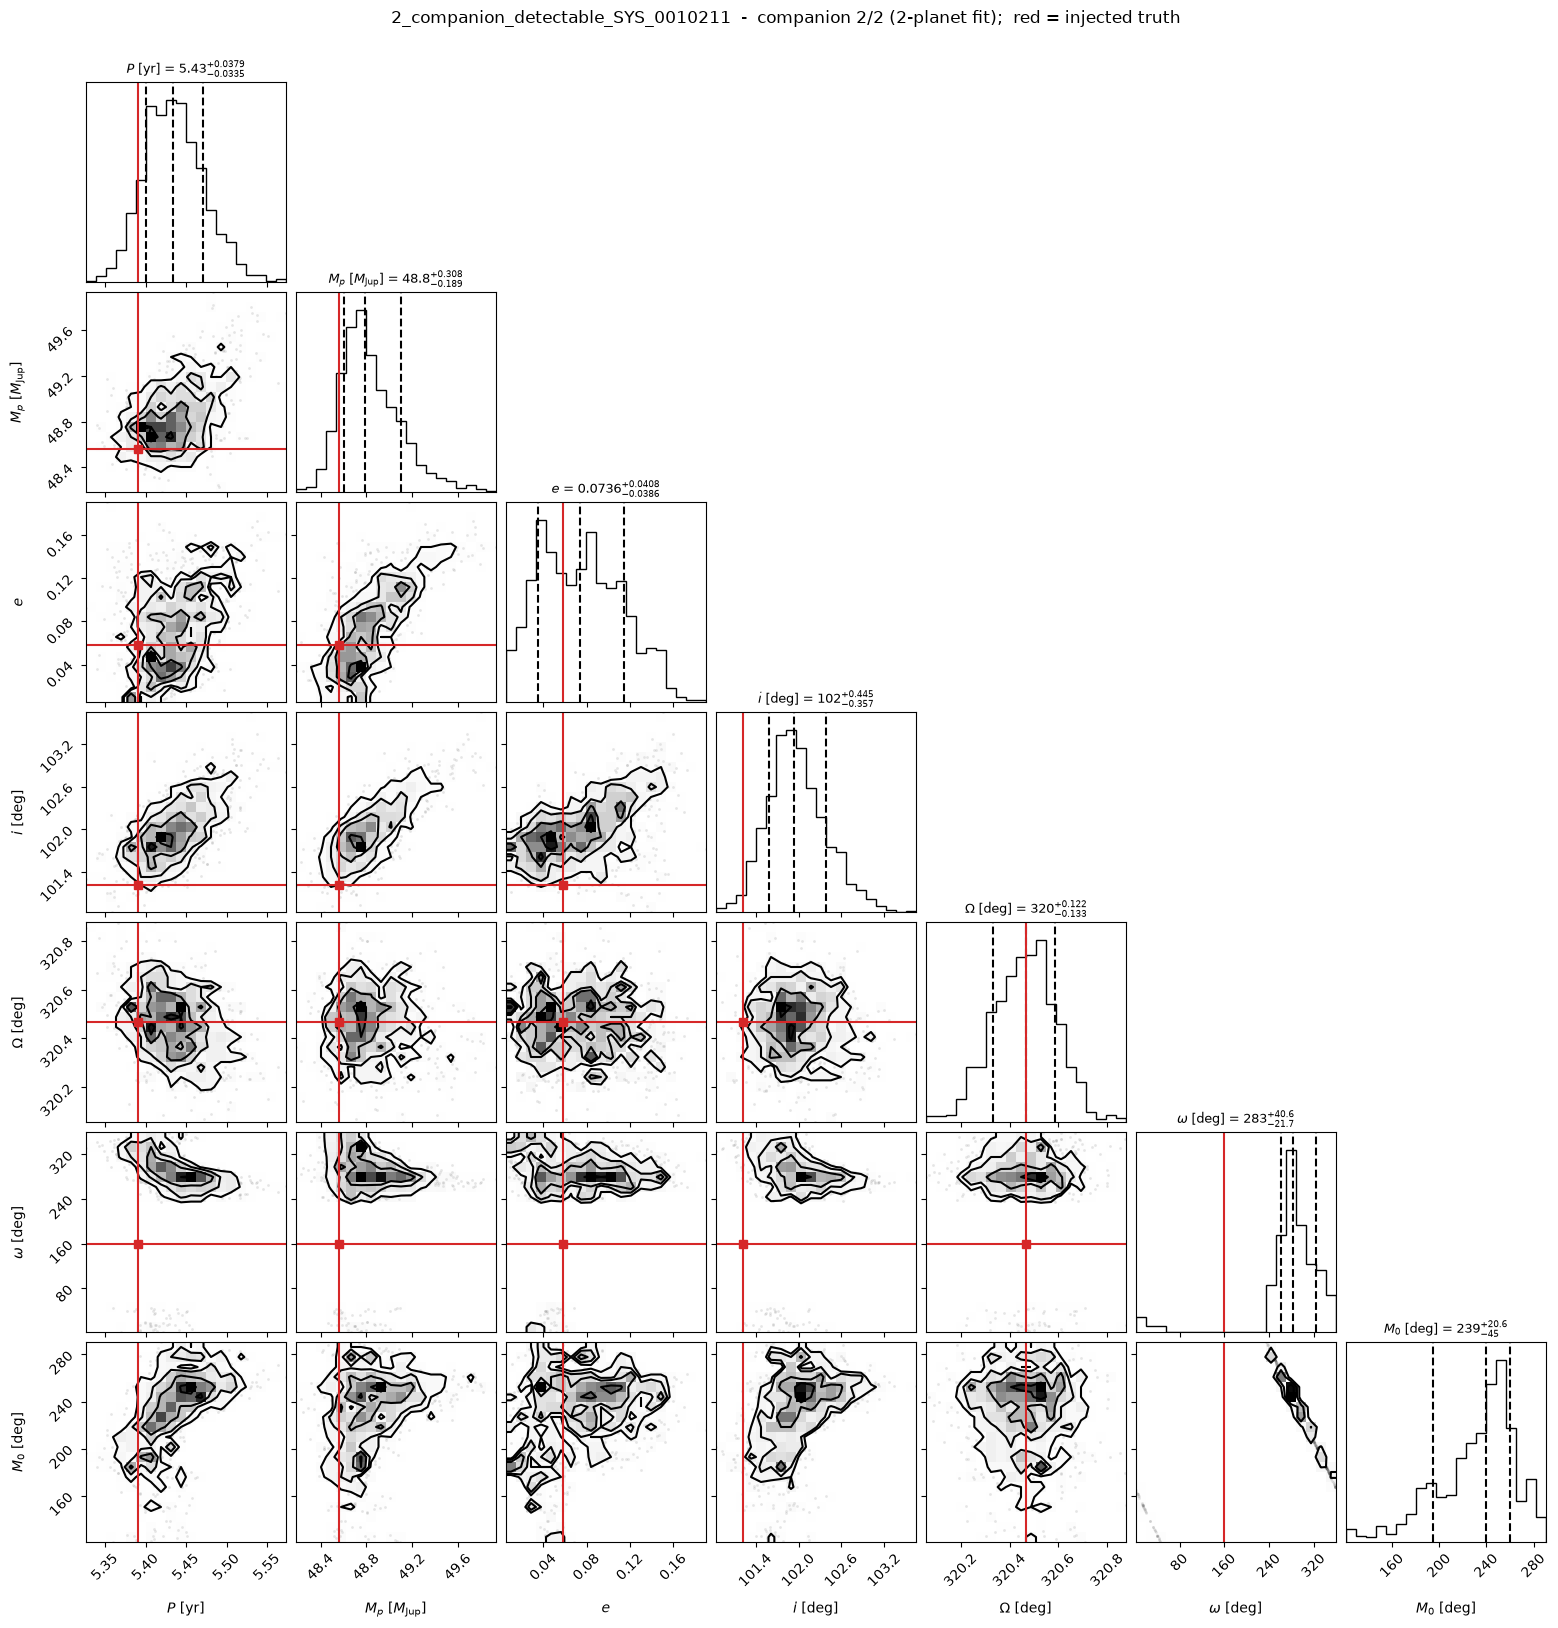

In [18]:
import corner

# Corner plot of the recovered orbital parameters vs. the injected truth (red),
# using the fit whose planet count matches the injected system; one figure per
# injected companion.
recover_order = int(truth["n_planets"])
corner_labels = [
    r"$P$ [yr]", r"$M_p$ [$M_{\rm Jup}$]", r"$e$", r"$i$ [deg]",
    r"$\Omega$ [deg]", r"$\omega$ [deg]", r"$M_0$ [deg]",
]

if recover_order == 0:
    print("Companion-free control: no injected orbital parameters to compare.")
elif recover_order not in fits:
    print(f"No {recover_order}-planet fit available; ran orders {sorted(fits)}.")
else:
    injected = injected_planets(truth)
    samples = fits[recover_order]["samples"]
    for idx in range(1, recover_order + 1):
        posterior = np.column_stack([
            np.asarray(samples[f"period_years_{idx}"]),
            np.asarray(samples[f"mass_mjup_{idx}"]),
            np.asarray(samples[f"eccentricity_{idx}"]),
            np.degrees(np.arccos(np.clip(np.asarray(samples[f"cos_i_{idx}"]), -1.0, 1.0))),
            np.degrees(np.asarray(samples[f"Omega_{idx}"])),
            np.degrees(np.asarray(samples[f"omega_{idx}"])),
            np.degrees(np.asarray(samples[f"M0_{idx}"])),
        ])
        p = injected[idx - 1]
        truth_vec = [
            p["period_years"], p["mass_msun"] / MJUP_TO_MSUN, p["eccentricity"],
            np.degrees(np.arccos(np.clip(p["cos_i"], -1.0, 1.0))),
            np.degrees(p["Omega"]), np.degrees(p["omega"]), np.degrees(p["M0"]),
        ]
        fig = corner.corner(
            posterior, labels=corner_labels, truths=truth_vec, truth_color="C3",
            quantiles=[0.16, 0.5, 0.84], show_titles=True, title_fmt=".3g",
            title_kwargs={"fontsize": 9},
        )
        fig.suptitle(
            f"{dataset['system_id']}  -  companion {idx}/{recover_order} "
            f"({recover_order}-planet fit);  red = injected truth",
            y=1.02, fontsize=12,
        )
        plt.show()


## Interpretation checklist

- Require multiple chains with $\hat R \approx 1$, adequate effective sample sizes, and few/no divergences before interpreting a fit.
- A truth-seeded run only tests whether the injected local mode is recoverable. Set `USE_INJECTED_INIT=False` and try several seeds for a blind-search test.
- Periods much longer than the observing baseline will be weakly identified and covariant with proper motion/acceleration.
- WAIC is a convenience diagnostic here, not a substitute for injection-recovery calibration or a carefully validated model-evidence calculation.
- The fitted along-scan jitter (`log_al_jitter_mas`, added in quadrature to the reported error) is expected to be nonzero because the epoch table reports `sigma_reported`, a different uncertainty construction from the `sigma_UEVA` actually used to inject scatter.